<a href="https://colab.research.google.com/github/me1-3/Emsc2010-GroupProject-Assess2/blob/main/EMSC2010_Group_Project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010 Group Project template

## 1. Project Overview
Group name: Ocean's Eleven Variables

Project week: 2

Project title: Bayesian analysis of fisheries

Datasets used (name and source):

Name of dataset used: *'Reported retained annual catch from Commonwealth fisheries logbooks'*

Link to dataset used (before it was cleaned): https://data.gov.au/data/dataset/reported-retained-annual-catch-from-commonwealth-fisheries-logbooks

Link to dataset used (after it was cleaned): https://1drv.ms/x/c/26adf2a591d32605/IQDuOhk5HWbrTof8_6O0BFxvAbv4HGjMEXTqEggy7y4yFCY?e=4od6se

## 2. Roles and contributions

| Role | Primary | Deputy | Completed? | Notes |
| :--- | :--- | :--- | :--- | :--- |
| Github & integration | Mel | Emily | Yes| n/a|
| Data steward | Charlotte | Leo | Yes| n/a|
| Analysis / modelling | Georgie | Jiah | No| deputy completed|
| Visualisation / interpretation | Jiah | Charlotte | Yes| n/a|
| Narrative | Leo | Georgie | Yes | n/a|
| Quality Control / Reproducibility  | Emily | Mel | Yes | n/a|


## 3. Deputy Interventions


* Role affected: Analysis/modelling

* Reason (e.g. missed deadline, absence, etc.): Miscommunication. The deadline was set as Tuesday however due to no time aspect it was completed by the deputy on Tuesday evening before the deadline had offically passed.

* Deputy action taken: The deputy completed all of the analysis/modelling code.

* Impact on workflow: No impact on workflow for other members of the group.



Changes outlined below should be implemented to prevent this happening in future weeks:



1.   Specifying completion time and date for the deadline to avoid future misunderstandings.
2. Progress reports and updates of work from team members before their deadlines, to manage group exceptions.
3.   If members of the group think that the deputy needs to step in, this should be communicated to the primary and the rest of the group.
4.   Group discussions should involve every member of the group and  be put in writing in the group chat or on Canvas so that expectations are clear and everyone informed.
5. Responsive replies to team member messages & inquires for time management.

## 4. Pre-submission checklist
* Notebook runs from top to bottom.
* Datafiles are included in the GitHub repository.
* Commits include meaningful information.
* Each group member has included a brief reflection in the notebook.
* Repository has been shared with the teaching team once your project is completed.

# Start your group project here

**Aim:** To use Bayes' theorem to determine the posterior probability that  the current mean catch rate of the commonwealth fisheries from 2013-2023 is higher than from 2003-2012.

Firstly, we have to define our hypothesis.
For this notebook our hypothesis is:
The current mean catch rate of the commonwealth fisheries is higher than it has been from 2003-2012.

Baye's theorem was used as its combinations of likelihoods and priors provide a reliable estimate of means and standard deviations.

Then we added our chosen, cleaned dataset to the colab notebook

Notes about how the data set was cleaned:
- The data was sorted from lowest to highest for the year column
- As the data period we were looking at was 2003-2023, the year 2002 was deleted
- The data was sorted from Z-A for the Gear column
- As the Gear variable we were looking at was Trawl, all of the others were deleted

In [ ]:
#Jiah coded data modelling and graphs

#IMPORT REQUIRED LIBRARIES FOR BAYESIAN MODELLING AND PLOTTING

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pymc as pm
import arviz as az

We then imported all important libraries, such as pyMC, for our specific modelling and plotting requirements

In [ ]:
#IMPORTING THE SPREADSHEET DATASET INTO THE CODE

spreadsheet_name = 'annual-logbook-catch-data-to-end-2023 (1).xlsx'
worksheet_name = 'annual-logbook-catch-data'
df = pd.read_excel(spreadsheet_name, sheet_name=worksheet_name)

In [ ]:
df.head()

,FISHERY,GEAR,YEAR,COMMON_NAME,SCIENTIFIC_NAME,CAAB,RETAINED_CATCH_KG,DATA_SOURCE
0,CSF,Trawl,2003,Alfonsino,Beryx splendens,37258002.0,58640,Logbook
1,CSF,Trawl,2003,Bar Rockcod,Epinephelus ergastularius & Epinephelus septem...,37311910.0,1630,Logbook
2,CSF,Trawl,2003,Coral Trout (mixed),Plectropomus spp & Variola spp,37311905.0,9,Logbook
3,CSF,Trawl,2003,Gemfish,Rexea solandri,37439002.0,2555,Logbook
4,CSF,Trawl,2003,Goldband snappers,Pristipomoides multidens & Pristipomoides typus,37346901.0,5,Logbook


In [ ]:
# Log-transform retained catch data
# Retained catch is measured in kg.
# The data are right-skewed, so a log10 transformation is used to reduce skewness
# and make the values more suitable for Bayesian modelling.

df["log10_retained_catch"] = np.log10(df["RETAINED_CATCH_KG"])

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

This is the printed cleaned data set from 2003 - 2023, showing the retained catch weight and the year it was caught. This data was then seperated into the two groups of interest and plotted in the histogram shown below.

2002 data was excluded from this notebook as the recorded data from the Commonwealth fisheries website was incomplete.

The histogram provides a visual representation of the two data sets and any visual variability between them before further probability is calculated.

In [ ]:
#SELECT EARLY YEAR GROUPS FROM THE DATASET

data_early = df[(df["YEAR"] <= 2012)]["RETAINED_CATCH_KG"].dropna()
data_early = data_early[data_early>0]
data_early = np.log10(data_early)

#SELECT RECENT YEAR GROUPS FROM THE DATASET
data_recent = df[(df["YEAR"] >= 2013)]["RETAINED_CATCH_KG"].dropna()
data_recent = data_recent[data_recent>0]
data_recent = np.log10(data_recent)

As seen above, the data was transformed using np.log10 in order to better visualise its distribution and handle the large range of values. This action makes the data more manageable for analysis and plotting. It also helps in making the distribution more symmetrical and closer to a normal distribution, something that can be beneficial for certain statistical models like the Bayesian model used in this project.

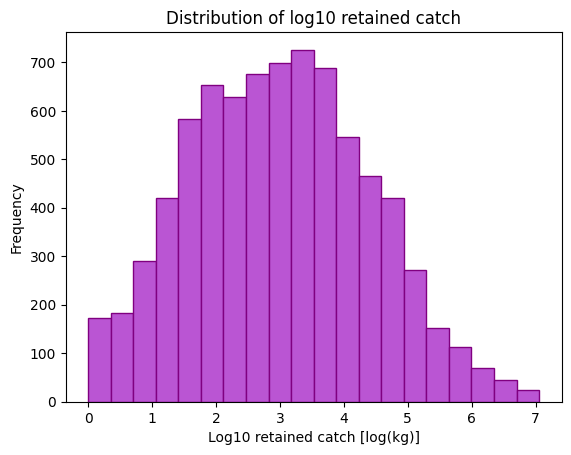

In [ ]:
#PLOT HISTOGRAMS TO VISUALISE DISTRIBUTION OF CATCH FOR EACH GROUP
plt.hist(df["log10_retained_catch"], bins=20, color="mediumorchid", edgecolor="purple")

#LABELS
plt.xlabel("Log10 retained catch [log(kg)]")
plt.ylabel("Frequency")
plt.title("Distribution of log10 retained catch")

#SHOW
plt.show() #show plot

The figure above shows the frequency of retained catch weight as a logarithmic scale due to wide variation. The plot exhibits slight positive skewness, indicating that average retained catch is lower than the middle-value. This plot makes sense given that we are looking at data for multiple fish species, so would expect to see a lot of variation, and that a very high retained catch is probably not as common as quite a low one.

The Baysian model was then used to plot the distributions of the previous mean and current mean as well as their 94% intervals respectively.

For this project, the 94% confindence interval was calculated to determine where 94% of all retained catches for both the current and previous years fell. 20,000 samples were obtained from each posterier.

Retained catch was measured in kilograms and showed a right-skewed distribution, with some large catch values. A log10 transformation was applied to reduce skewness and make the data more suitable for Bayesian modelling. While the model was fitted in log10 space, posterior samples were later converted back to kilograms so the results could be interpreted in absolute catch units.

<Axes: title={'center': 'mu'}>

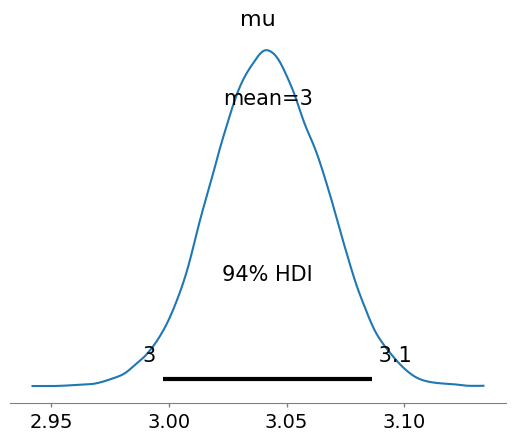

In [ ]:
#BAYESIAN MODEL ESTIMATING MEAN CATCH FOR EARLY YEARS

with pm.Model() as early_model:

  # Prior for the mean — Normal centered at your best prior guess with sigma representing the uncertainty in that guess
  mu = pm.Normal("mu", mu = 3, sigma = 2)

  # Prior for std of heights — HalfNormal with a standard deviation of 2.
  sigma = pm.HalfNormal ("sigma", sigma = 2)

  # Likelihood given the data
  obs = pm.Normal ("obs", mu = mu, sigma = sigma, observed = data_early)

   # Obtain 20,000 samples from the posterior
  trace_early = pm.sample(20000, tune = 2000, return_inferencedata = True, progressbar = False)

  # Plot the posterior distribution for the mean
az.plot_posterior(trace_early, var_names=["mu"])

Posterior distribution for the log of mean retained catch for early years. This distribution supports our prior guess for the mean, as the HDI includes 3.

<Axes: title={'center': 'mu'}>

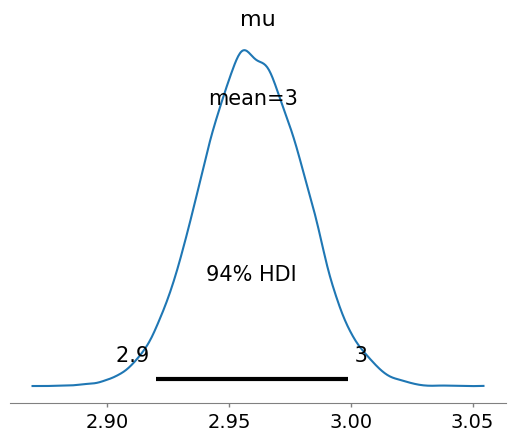

In [ ]:
#BAYESIAN MODEL ESTIMATING MEAN CATCH FOR RECENT YEARS

with pm.Model() as recent_model:

  # Prior for the mean — Normal centered at your best prior guess with sigma representing the uncertainty in that guess
  mu = pm.Normal("mu", mu = 3, sigma = 2)

  # Prior for std of heights — HalfNormal for standard deviation with sigma = 2.
  sigma = pm.HalfNormal ("sigma", sigma = 2)

  # Likelihood given the data
  obs = pm.Normal ("obs", mu = mu, sigma = sigma, observed = data_recent)

   # Obtain 20,000 samples from the posterior
  trace_recent = pm.sample(20000, tune = 2000, return_inferencedata = True, progressbar = False)

  # Plot the posterior distribution for the mean
az.plot_posterior(trace_recent, var_names=["mu"])

Posterior distribution for the log of mean retained catch for recent years. This distribution also supports our prior guess, although 3 is at the other end of the HDI.

Next was to extract the posterior samples of each mean. After extraction, the difference between the current and previous means were calculated and plotted as the histogram below.

This was to visually represent the data that doesn't overlap between the current and previous retained catch data

In [ ]:
#EXTRACT POSTERIOR SAMPLES OF THE MEAN FROM BOTH MODELS

mu_samples_early = trace_early.posterior["mu"].values.flatten()
mu_samples_recent = trace_recent.posterior["mu"].values.flatten()

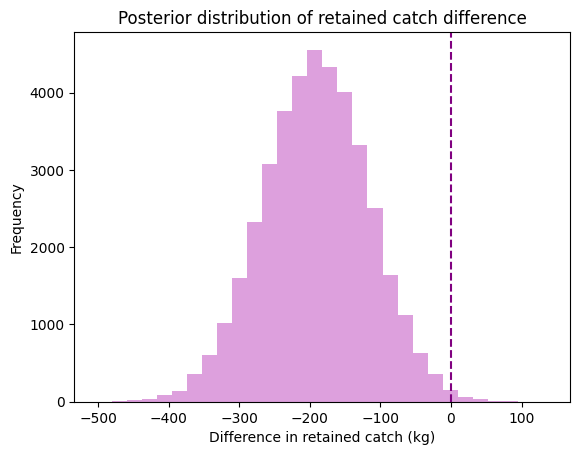

In [ ]:
#PLOT DISTRIBUTION OF DIFFERENCE IN MEAN CATCH BETWEEN GROUPS
# We already have mu_samples_early and mu_samples_recent

mean_group_1_log = mu_samples_recent # Corresponds to recent catch means
mean_group_2_log = mu_samples_early  # Corresponds to early catch means

mean_group_1_kg = 10 ** mean_group_1_log
mean_group_2_kg = 10 ** mean_group_2_log

difference_kg = mean_group_1_kg - mean_group_2_kg

#HISTOGRAM
plt.hist(difference_kg, bins=30, color="plum")

plt.axvline(0, color="purple", linestyle="dashed")

#LABELS
plt.xlabel("Difference in retained catch (kg)")
plt.ylabel("Frequency")
plt.title("Posterior distribution of retained catch difference")

plt.show()

Histogram of the difference in mean retained catch between recent and early years.

Because differences in log-transformed values represent ratios rather than absolute differences, the posterior samples were converted back to kilograms before calculating the difference between recent and early mean retained catch. This makes the result easier to interpret in the original measurement scale.

### Re-evaluating Differences in Original Units (kg)

As per the feedback, while log transformations are useful for modeling, interpreting the differences in the original measurement space (kilograms) can be more intuitive. We will convert the posterior samples of the mean back from log10 scale to kilograms, calculate their differences, and then find the 95% Highest Density Interval (HDI) for these differences.

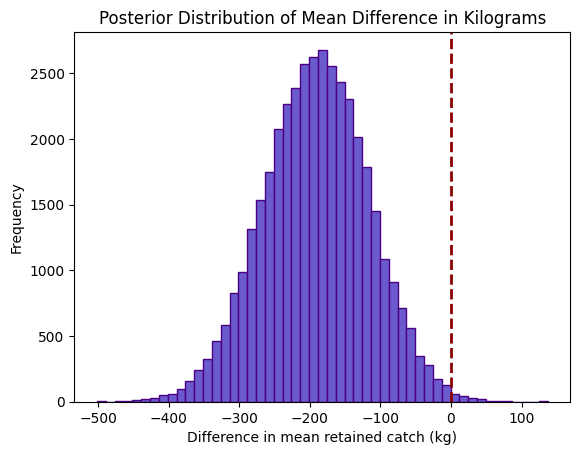

In [ ]:
# Convert the log10 posterior mean samples back to original scale (kg)
mean_kg_samples_early = 10**mu_samples_early
mean_kg_samples_recent = 10**mu_samples_recent

# Calculate the posterior difference in kilograms
diff_kg = mean_kg_samples_recent - mean_kg_samples_early

# Plot posterior distribution of the difference in kilograms
plt.hist(diff_kg, bins=51, color="slateblue", edgecolor="indigo")

# Zero reference line
plt.axvline(0, color="darkred", linestyle="dashed", linewidth=2)

plt.xlabel("Difference in mean retained catch (kg)")
plt.ylabel("Frequency")
plt.title("Posterior Distribution of Mean Difference in Kilograms")

plt.show()

The histogram above shows the distribution of the difference in mean catch in actual kilograms. Now, let's calculate the 95% HDI for this difference.

In [ ]:
# Calculate the 95% Highest Density Interval (HDI) for the difference in kilograms
hdi_diff_kg = az.hdi(diff_kg, hdi_prob=0.95)
print(f"95% HDI for the difference in mean catch (recent - early) in kg: {hdi_diff_kg}")

# Calculate the probability that the recent mean catch is higher than the early mean catch in kg
prob_recent_greater_kg = np.mean(diff_kg > 0)
print(f"Probability that recent mean catch is higher than early mean catch (in kg): {prob_recent_greater_kg}")

95% HDI for the difference in mean catch (recent - early) in kg: [-336.87773917  -45.4848687 ]
Probability that recent mean catch is higher than early mean catch (in kg): 0.004125


By performing this transformation, you get a much clearer picture:

*   The **95% HDI for `difference_kg`** will tell you the credible range for the *absolute difference* in mean catch in kilograms. If this interval *includes zero*, it means there is no credible difference between the two periods in absolute terms. If the entire interval is below zero (as is likely the case given your `mu_diff` result), it strongly suggests the recent mean catch is credibly lower.
*   The **probability (`np.mean(diff_kg > 0)`)** now directly answers how often the sampled difference in kilograms was positive, giving a direct probability that the recent mean catch was higher in actual kilograms.

The 95% highest density interval was then calculated before lastly the probability of the current catch rates baing higher than the previous catch rates were calculated.

In [ ]:
#CALCULATE THE 95% HIGHEST DENSITY INTERVAL (CREDIBLE INTERVAL)

az.hdi(mu_diff, hdi_prob = 0.95)

array([-0.14491601, -0.02114117])

In [ ]:
#CALCULATE PROBABILITY THAT RECENT MEAN CATCH IS GREATER THAN EARLY MEAN CATCH

np.mean(mu_diff > 0)

np.float64(0.004125)

In [ ]:
print("Probability that recent mean catch is higher than early mean catch =", np.mean(mu_diff > 0))

Probability that recent mean catch is higher than early mean catch = 0.004125


The probability of the mean catch rate being higher that the previous catch
rate is ~0.004, meaning their is no significant increase in the catch rate between the two data sets and our hypothesis has been disproven.

**Week-7 Group Project Reflections:**

**Jiah -** For the Week 7 group project, I contributed both as the Analysis Modelling Lead and Visualisation/Interpretation Leads (roles 3 and 4). My role involved applying the concepts from the lectorial and practical sessions on hypothesis testing and Bayesian modelling using PyMC to our dataset in a structured and reproducible way. I uploaded the cleaned up dataset in the code, and developed the analysis models for the early and recent data groups, ensuring that appropriate priors were used and that the posterior outputs were generated correctly. I also supported the visualisation of results by producing clear histograms and posterior distribution plots, using consistent colour schemes and labels to improve readability. In addition, I assisted and supported the interpretation of the results, particularly understanding what the difference in means and the credible interval indicated about our data, in order to help the group understand the statistical results in the context of our research question. In a nutshell, this week strengthened my understanding of Bayesian analysis and highlighted the importance of clear modelling and visualisation in communicating scientific findings effectively.


**Charlotte** - For the Week 7 group project, I was primary for the Data Steward role. My role involved finding and cleaning up the dataset, making sure everyone in the group knew where to find the cleaned dataset and uploading the chosen dataset into our Colab. The main thing I learnt from my role was how to further my skills with Excel. I learnt multiple shortcuts that helped me to clean the data efficiently and minimise mistakes. The first thing I did was sort the data from highest to lowest for the year column, which went from 2002 to 2023. Our chosen time period for this group project was 2003-2023 so the data from the year 2002 was deleted. Next, I sort the gear column from A-Z in order to make it easier for myself to isolate the gear variable we would be working with. The chosen gear variable was Trawl so all the others were deleted.

**Leo:** My role for this project was the Narrative Lead. To fulfill my duty, I initially focused on writting out the individual steps for each part of our project before working backwards from our data and calculations to determine a fitting aim and hypothesis for this notebook. The main thing I have learnt from this role is how to follow the flow of the notebook and better understand the steps taken in each step leading up to the answer.

**Emily**: My role for this project was Quality Control/Reproducibility Lead (role 6). My first task was to run all the code to make sure it worked properly, and check that our data were accessible. This went smoothly. I made some minor adjustments to our explanations and annotations to clarify the exact process for some steps, and added captions to our figures. This role reminded me to make sure I was keeping our inital topic/hypothesis in mind and try to view the code as an outsider. I found it really useful; this persepctive made me pick up on things I wouldn't have otherwise.

Mel: My role for this project was the GitHub repository and integration lead, which meant that I created and shared the colab to all other members of the team, as well as to commit & submit the final project. This was critical in the early stage of the assignment in setting up, as well as providing a record of work and contributions. Furthermore acting as the final quality check, making sure everything runs before submission. Through this role I learned the importance of record in maintenance, and reliability.



**Georgie:** My role was analysis modelling which I planned to complete on Tuesday evening before the deadline. As outlined in the intervention section, this role was completed by the deputy due to a lack of communication, so instead my role this week focused on improving group communication for future. The main point was that discussions need to happen with the involvement of the whole group, as in this case, to my understanding the deputy discussed with a few others in the group that I had not begun my role and they decided that she should step in. At no point was this communicated to me or the rest of the group, so I only found out when I went to start the analysis modelling. I wrote a few points on changes we could make to avoid misunderstandings for future projects.